<a href="https://colab.research.google.com/github/riskoptima/blog/blob/master/VIX_SPIKE_DETECTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

VIX SPIKE PREDICTION: HESTON + XGBOOST FOR 1-DTE SPX OPTIONS

NEW Spike definition: VIX increases by >15.0% from previous day
Example: If VIX = 15 today, spike = VIX > 15.75 tomorrow
Prediction threshold: 40% (High Confidence)

Data: 1254 days (2020-12-01 to 2025-11-26)

VIX Spikes (>15% increase): 53 / 1253 days (4.2%)

Example spike days:
  2020-12-18: VIX 21.57 → 25.16 (+16.6%)
  2020-12-31: VIX 22.75 → 26.97 (+18.5%)
  2021-01-26: VIX 23.02 → 37.21 (+61.6%)
  2021-02-24: VIX 21.34 → 28.89 (+35.4%)
  2021-05-07: VIX 16.69 → 19.66 (+17.8%)

CREATING FEATURES
✓ Market features created

GENERATING HESTON FEATURES (ROLLING WINDOW)
  50/245 (20%)
  100/245 (41%)
  150/245 (61%)
  200/245 (82%)
✓ Heston features generated in 0.9s (4ms per window)

Dataset: 245 samples, 30 features, 14 spikes (5.7%)

Train: 196 | Test: 49 (2025-09-18 to 2025-11-25)
Test spikes: 2 (4.1%)

TRAINING XGBOOST
✓ Model trained

PERFORMANCE METRICS

Spike Definition: VIX increases >15% from previous day
Prediction

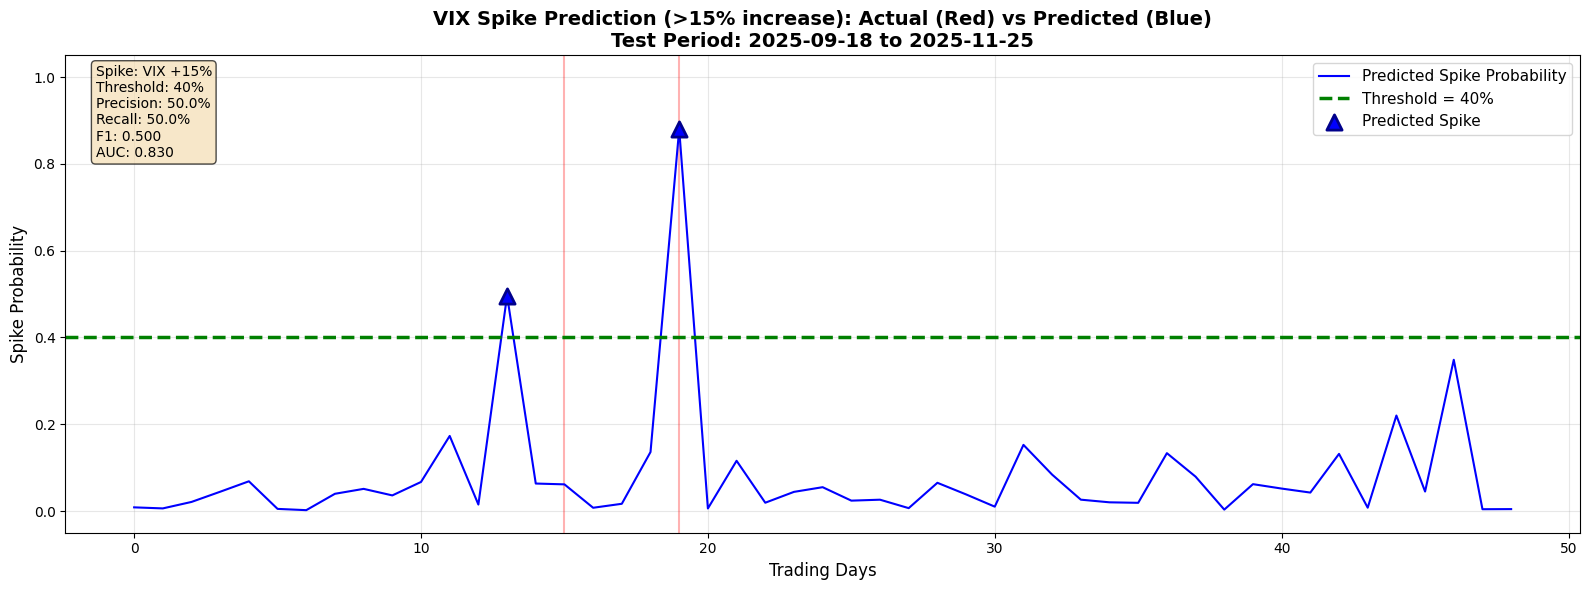

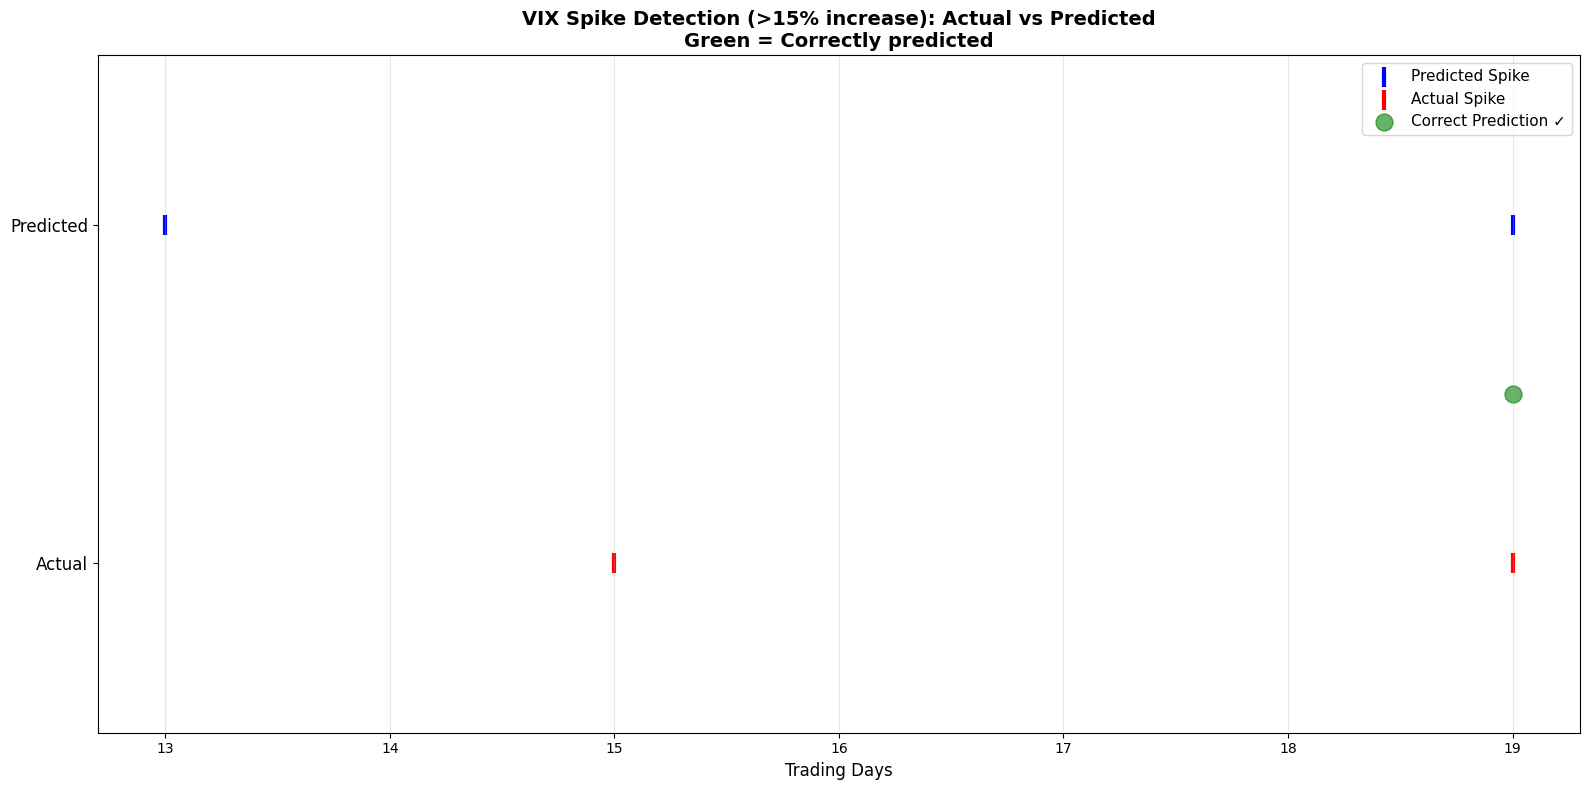

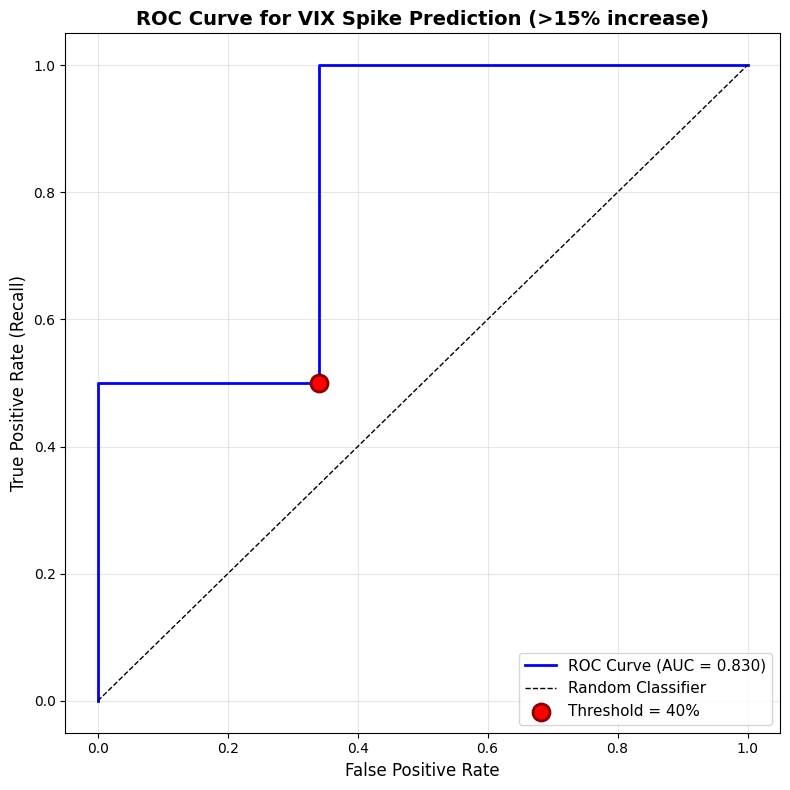

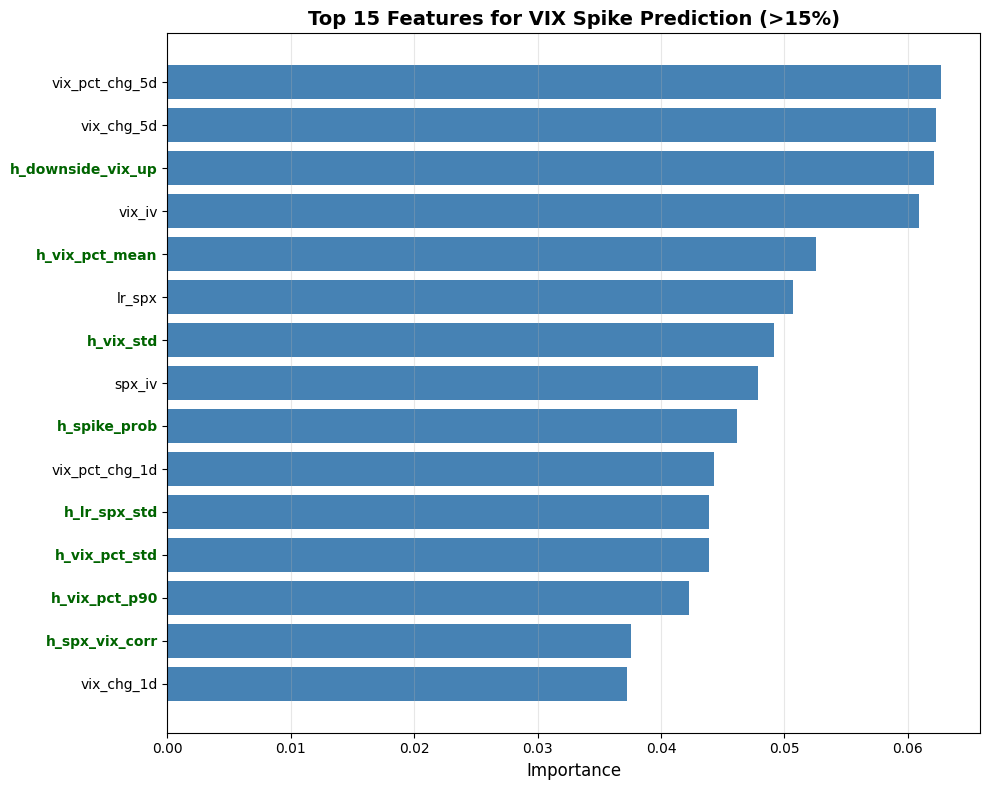

In [18]:
"""
VIX Spike Prediction for 1-DTE SPX Options Trading
Heston Model + XGBoost Classifier
NEW: Spike = VIX increases by >5% from previous day, Threshold = 50%
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

SPIKE_THRESHOLD = 0.15  # VIX spike = >5% increase from previous day
TRAIN_WINDOW = 4 * 252  # 4 years for rolling calibration
N_PATHS = 2000          # MC paths per simulation
PREDICTION_THRESHOLD = 0.40  # Only predict spike when 50%+ confident

print("="*80)
print("VIX SPIKE PREDICTION: HESTON + XGBOOST FOR 1-DTE SPX OPTIONS")
print("="*80)
print(f"\nNEW Spike definition: VIX increases by >{SPIKE_THRESHOLD:.1%} from previous day")
print(f"Example: If VIX = 15 today, spike = VIX > 15.75 tomorrow")
print(f"Prediction threshold: {PREDICTION_THRESHOLD:.0%} (High Confidence)")

# ============================================================================
# LOAD DATA
# ============================================================================

df = pd.read_csv('/content/SPX_VIX_DATA.csv', encoding='utf-8-sig')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
df_clean = df.dropna(subset=['LR_SPX', 'LR_SPX_ IV', 'LR_VIX', 'LR_VIX_IV']).copy()
df_clean = df_clean.reset_index(drop=True)

print(f"\nData: {len(df_clean)} days ({df_clean['Date'].iloc[0].date()} to {df_clean['Date'].iloc[-1].date()})")

# ============================================================================
# CREATE NEW SPIKE INDICATOR: VIX % CHANGE > 5%
# ============================================================================

# Calculate VIX percentage change from previous day
df_clean['VIX_pct_change'] = df_clean['VIX'].pct_change()

# Create spike indicator for NEXT day
# Spike = VIX increases by more than 5% from current day to next day
df_clean['VIX_Spike_Next'] = (df_clean['VIX_pct_change'].shift(-1) > SPIKE_THRESHOLD).astype(int)

# Remove last row (no target)
df_clean = df_clean[:-1].copy()

spike_count = df_clean['VIX_Spike_Next'].sum()
print(f"\nVIX Spikes (>{SPIKE_THRESHOLD:.0%} increase): {spike_count} / {len(df_clean)} days ({spike_count/len(df_clean)*100:.1f}%)")

# Show some examples
print(f"\nExample spike days:")
spike_days = df_clean[df_clean['VIX_Spike_Next'] == 1].head(5)
for idx, row in spike_days.iterrows():
    vix_today = row['VIX']
    vix_tomorrow = df_clean.loc[idx+1, 'VIX'] if idx+1 < len(df_clean) else None
    if vix_tomorrow:
        pct_change = (vix_tomorrow - vix_today) / vix_today
        print(f"  {row['Date'].date()}: VIX {vix_today:.2f} → {vix_tomorrow:.2f} (+{pct_change:.1%})")

# ============================================================================
# HESTON MODEL FUNCTIONS
# ============================================================================

def estimate_heston_params(df_train):
    """Estimate Heston parameters from training window"""

    lr_S = df_train['LR_SPX'].values
    lr_VS = df_train['LR_SPX_ IV'].values
    lr_X = df_train['LR_VIX'].values
    lr_VX = df_train['LR_VIX_IV'].values

    VS = df_train['SPX_ IV'].values
    VX = df_train['VIX_IV'].values
    X = df_train['VIX'].values

    # Correlations (all 6)
    corr_matrix = np.corrcoef(np.column_stack([lr_S, lr_VS, lr_X, lr_VX]).T)

    # Mean reversion parameters
    VS_mean = np.mean(VS)
    kappa_VS = -np.sum(np.diff(VS) * (VS[:-1] - VS_mean)) / (np.sum((VS[:-1] - VS_mean)**2) + 1e-10)

    X_mean = np.mean(X)
    kappa_X = -np.sum(np.diff(X) * (X[:-1] - X_mean)) / (np.sum((X[:-1] - X_mean)**2) + 1e-10)

    VX_mean = np.mean(VX)
    kappa_VX = -np.sum(np.diff(VX) * (VX[:-1] - VX_mean)) / (np.sum((VX[:-1] - VX_mean)**2) + 1e-10)

    params = {
        'mu_S': np.mean(lr_S) * 252,
        'kappa_VS': max(kappa_VS * 252, 0.1),
        'theta_VS': VS_mean,
        'sigma_VS': np.std(lr_VS) * np.sqrt(252),
        'kappa_X': max(kappa_X * 252, 0.1),
        'theta_X': X_mean,
        'kappa_VX': max(kappa_VX * 252, 0.1),
        'theta_VX': VX_mean,
        'sigma_VX': np.std(lr_VX) * np.sqrt(252)
    }

    # Build correlation matrix
    Sigma = np.array([
        [1.0, corr_matrix[0,1], corr_matrix[0,2], corr_matrix[0,3]],
        [corr_matrix[0,1], 1.0, corr_matrix[1,2], corr_matrix[1,3]],
        [corr_matrix[0,2], corr_matrix[1,2], 1.0, corr_matrix[2,3]],
        [corr_matrix[0,3], corr_matrix[1,3], corr_matrix[2,3], 1.0]
    ])

    # Ensure positive definite
    eig = np.linalg.eigvals(Sigma)
    if np.min(eig) <= 1e-10:
        eps = abs(np.min(eig)) + 0.01
        Sigma = Sigma + np.eye(4) * eps
        Sigma = np.diag(1/np.sqrt(np.diag(Sigma))) @ Sigma @ np.diag(1/np.sqrt(np.diag(Sigma)))

    L = np.linalg.cholesky(Sigma)

    return params, L


def simulate_heston_1day(S0, VS0, X0, VX0, params, L, n_paths=2000):
    """Simulate 1 day ahead with Heston model"""

    dt = 1/252
    eps = 1e-8

    # Generate correlated shocks
    Z = np.random.standard_normal((n_paths, 4))
    dW = (L @ Z.T).T * np.sqrt(dt)

    VS0 = max(VS0, eps)
    VX0 = max(VX0, eps)

    # SPX
    log_S_next = np.log(S0) + (params['mu_S'] - 0.5*VS0)*dt + np.sqrt(VS0)*dW[:, 0]
    S_next = np.exp(log_S_next)

    # VIX
    X_next = X0 + params['kappa_X']*(params['theta_X'] - X0)*dt + np.sqrt(VX0)*X0*dW[:, 2]
    X_next = np.maximum(X_next, eps)

    return S_next, X_next


def extract_heston_features(S0, VS0, X0, VX0, params, L):
    """Generate features from Heston MC simulation"""

    S_sim, X_sim = simulate_heston_1day(S0, VS0, X0, VX0, params, L, n_paths=N_PATHS)

    # VIX percentage change (not log return)
    vix_pct_change_sim = (X_sim - X0) / X0
    lr_S_sim = np.log(S_sim / S0)

    return {
        # VIX distribution
        'h_vix_mean': X_sim.mean(),
        'h_vix_std': X_sim.std(),
        'h_vix_p90': np.percentile(X_sim, 90),
        'h_vix_p95': np.percentile(X_sim, 95),

        # VIX % change distribution
        'h_vix_pct_mean': vix_pct_change_sim.mean(),
        'h_vix_pct_std': vix_pct_change_sim.std(),
        'h_vix_pct_skew': stats.skew(vix_pct_change_sim),
        'h_vix_pct_p90': np.percentile(vix_pct_change_sim, 90),
        'h_vix_pct_p95': np.percentile(vix_pct_change_sim, 95),

        # SPIKE PROBABILITY (key feature) - % change > 5%
        'h_spike_prob': (vix_pct_change_sim > SPIKE_THRESHOLD).mean(),

        # SPX features
        'h_spx_std': S_sim.std(),
        'h_lr_spx_mean': lr_S_sim.mean(),
        'h_lr_spx_std': lr_S_sim.std(),

        # Joint dynamics
        'h_spx_vix_corr': np.corrcoef(lr_S_sim, vix_pct_change_sim)[0, 1],
        'h_downside_vix_up': ((lr_S_sim < -0.01) & (vix_pct_change_sim > 0.03)).mean(),
    }

# ============================================================================
# CREATE MARKET FEATURES
# ============================================================================

print(f"\n{'='*80}")
print("CREATING FEATURES")
print("="*80)

# VIX features
df_clean['vix'] = df_clean['VIX']
df_clean['vix_ma20'] = df_clean['VIX'].rolling(20).mean()
df_clean['vix_vs_ma20'] = (df_clean['VIX'] - df_clean['vix_ma20']) / df_clean['vix_ma20']
df_clean['vix_chg_1d'] = df_clean['VIX'].diff(1)
df_clean['vix_chg_5d'] = df_clean['VIX'].diff(5)
df_clean['vix_pct_chg_1d'] = df_clean['VIX_pct_change']
df_clean['vix_pct_chg_5d'] = df_clean['VIX'].pct_change(5)

# SPX features
df_clean['lr_spx'] = df_clean['LR_SPX']
df_clean['spx_vol_20'] = df_clean['LR_SPX'].rolling(20).std()
df_clean['spx_down_3d'] = (df_clean['LR_SPX'] < 0).rolling(3).sum()
df_clean['spx_down_5d'] = (df_clean['LR_SPX'] < 0).rolling(5).sum()

# IV features
df_clean['spx_iv'] = df_clean['SPX_ IV']
df_clean['vix_iv'] = df_clean['VIX_IV']

# Regime
df_clean['high_vix'] = (df_clean['VIX'] > 20).astype(int)
df_clean['very_high_vix'] = (df_clean['VIX'] > 30).astype(int)
df_clean['vol_expanding'] = (df_clean['spx_vol_20'] > df_clean['spx_vol_20'].shift(10)).astype(int)

market_features = ['vix', 'vix_vs_ma20', 'vix_chg_1d', 'vix_chg_5d',
                   'vix_pct_chg_1d', 'vix_pct_chg_5d',
                   'lr_spx', 'spx_vol_20', 'spx_down_3d', 'spx_down_5d',
                   'spx_iv', 'vix_iv', 'high_vix', 'very_high_vix', 'vol_expanding']

print("✓ Market features created")

# ============================================================================
# ROLLING WINDOW: GENERATE HESTON FEATURES
# ============================================================================

print(f"\n{'='*80}")
print("GENERATING HESTON FEATURES (ROLLING WINDOW)")
print("="*80)

n_windows = len(df_clean) - TRAIN_WINDOW
heston_features_list = []

import time
start = time.time()

for i in range(n_windows):
    df_train = df_clean.iloc[i:i+TRAIN_WINDOW]
    idx = i + TRAIN_WINDOW

    # Estimate Heston parameters
    params, L = estimate_heston_params(df_train)

    # Current state
    S0 = df_clean['SPX'].iloc[idx]
    VS0 = df_clean['SPX_ IV'].iloc[idx]
    X0 = df_clean['VIX'].iloc[idx]
    VX0 = df_clean['VIX_IV'].iloc[idx]

    # Extract features
    h_feat = extract_heston_features(S0, VS0, X0, VX0, params, L)
    h_feat['idx'] = idx
    heston_features_list.append(h_feat)

    if (i+1) % 50 == 0:
        print(f"  {i+1}/{n_windows} ({(i+1)/n_windows*100:.0f}%)")

elapsed = time.time() - start
print(f"✓ Heston features generated in {elapsed:.1f}s ({elapsed/n_windows*1000:.0f}ms per window)")

heston_df = pd.DataFrame(heston_features_list).set_index('idx')

# ============================================================================
# COMBINE FEATURES & PREPARE DATASET
# ============================================================================

# Combine market + Heston features
valid_idx = heston_df.index
X_market = df_clean.loc[valid_idx, market_features]
X_heston = heston_df
X = pd.concat([X_market, X_heston], axis=1)
y = df_clean.loc[valid_idx, 'VIX_Spike_Next']

# Remove NaN
valid = ~X.isna().any(axis=1)
X = X[valid]
y = y[valid]

print(f"\nDataset: {len(X)} samples, {X.shape[1]} features, {y.sum()} spikes ({y.sum()/len(y)*100:.1f}%)")

# ============================================================================
# TRAIN/TEST SPLIT (TIME-BASED)
# ============================================================================

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

dates_test = df_clean.loc[X_test.index, 'Date']

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)} ({dates_test.iloc[0].date()} to {dates_test.iloc[-1].date()})")
print(f"Test spikes: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)")

# ============================================================================
# TRAIN XGBOOST
# ============================================================================

print(f"\n{'='*80}")
print("TRAINING XGBOOST")
print("="*80)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("✓ Model trained")

# ============================================================================
# PREDICTIONS
# ============================================================================

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > PREDICTION_THRESHOLD).astype(int)

# ============================================================================
# EVALUATION
# ============================================================================

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print(f"\n{'='*80}")
print("PERFORMANCE METRICS")
print("="*80)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nSpike Definition: VIX increases >{SPIKE_THRESHOLD:.0%} from previous day")
print(f"Prediction Threshold: {PREDICTION_THRESHOLD:.0%}")

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {acc:.1%}")
print(f"  Precision: {prec:.1%} ← % of predicted spikes that were actual spikes")
print(f"  Recall:    {rec:.1%} ← % of actual spikes that were predicted")
print(f"  F1-Score:  {f1:.3f}")
print(f"  ROC-AUC:   {auc:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]} (correctly predicted no spike)")
print(f"  False Positives: {cm[0,1]} (predicted spike, no spike occurred)")
print(f"  False Negatives: {cm[1,0]} (missed actual spike)")
print(f"  True Positives:  {cm[1,1]} (correctly predicted spike)")

print(f"\nWith {PREDICTION_THRESHOLD:.0%} threshold:")
print(f"  You trade on {y_pred.sum()} days (only when {PREDICTION_THRESHOLD:.0%}+ confident)")
print(f"  Of those, {cm[1,1]} were actual spikes ({prec:.1%} precision)")

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
for i, row in importance.head(10).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.4f}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print(f"\n{'='*80}")
print("CREATING VISUALIZATIONS")
print("="*80)

# ============================================================================
# PLOT 1: PREDICTED VS ACTUAL SPIKES (TIME SERIES)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 6))

# Plot actual VIX spikes
actual_spikes = y_test.values
spike_dates = dates_test.values
spike_indices = np.arange(len(actual_spikes))

# Convert numpy datetime64 to string for display
start_date = pd.to_datetime(spike_dates[0]).strftime('%Y-%m-%d')
end_date = pd.to_datetime(spike_dates[-1]).strftime('%Y-%m-%d')

# Plot actual spikes as red vertical bars
for i, is_spike in enumerate(actual_spikes):
    if is_spike:
        ax.axvline(i, color='red', alpha=0.3, linewidth=1.5)

# Plot predicted spike probability as line
ax.plot(spike_indices, y_pred_proba, color='blue', linewidth=1.5, label='Predicted Spike Probability')

# Plot threshold
ax.axhline(PREDICTION_THRESHOLD, color='green', linestyle='--', linewidth=2.5,
           label=f'Threshold = {PREDICTION_THRESHOLD:.0%}')

# Highlight predicted spikes
predicted_spike_idx = np.where(y_pred == 1)[0]
ax.scatter(predicted_spike_idx, y_pred_proba[predicted_spike_idx],
           color='blue', s=120, marker='^', zorder=5, edgecolors='darkblue',
           linewidth=2, label='Predicted Spike')

ax.set_xlabel('Trading Days', fontsize=12)
ax.set_ylabel('Spike Probability', fontsize=12)
ax.set_title(f'VIX Spike Prediction (>{SPIKE_THRESHOLD:.0%} increase): Actual (Red) vs Predicted (Blue)\nTest Period: {start_date} to {end_date}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Add text box with stats
textstr = f'Spike: VIX +{SPIKE_THRESHOLD:.0%}\nThreshold: {PREDICTION_THRESHOLD:.0%}\nPrecision: {prec:.1%}\nRecall: {rec:.1%}\nF1: {f1:.3f}\nAUC: {auc:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('/content/vix_spike_prediction_5pct.png', dpi=150, bbox_inches='tight')
print("✓ Saved 'vix_spike_prediction_5pct.png'")

# ============================================================================
# PLOT 2: PREDICTED SPIKES VS ACTUAL SPIKES (CALENDAR VIEW)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 8))

actual_binary = actual_spikes
predicted_binary = y_pred

actual_label_added = False
predicted_label_added = False
correct_label_added = False

for i in range(len(spike_dates)):
    if actual_binary[i] == 1:
        if not actual_label_added:
            ax.scatter(i, 0, color='red', s=200, marker='|', linewidths=3, label='Actual Spike')
            actual_label_added = True
        else:
            ax.scatter(i, 0, color='red', s=200, marker='|', linewidths=3)

    if predicted_binary[i] == 1:
        if not predicted_label_added:
            ax.scatter(i, 1, color='blue', s=200, marker='|', linewidths=3, label='Predicted Spike')
            predicted_label_added = True
        else:
            ax.scatter(i, 1, color='blue', s=200, marker='|', linewidths=3)

    if actual_binary[i] == 1 and predicted_binary[i] == 1:
        if not correct_label_added:
            ax.scatter(i, 0.5, color='green', s=150, marker='o', alpha=0.6, label='Correct Prediction ✓')
            correct_label_added = True
        else:
            ax.scatter(i, 0.5, color='green', s=150, marker='o', alpha=0.6)

ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual', 'Predicted'], fontsize=12)
ax.set_xlabel('Trading Days', fontsize=12)
ax.set_title(f'VIX Spike Detection (>{SPIKE_THRESHOLD:.0%} increase): Actual vs Predicted\nGreen = Correctly predicted',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='x', alpha=0.3)
ax.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.savefig('/content/vix_spike_calendar_5pct.png', dpi=150, bbox_inches='tight')
print("✓ Saved 'vix_spike_calendar_5pct.png'")

# ============================================================================
# PLOT 3: ROC CURVE
# ============================================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

threshold_idx = np.argmin(np.abs(thresholds - PREDICTION_THRESHOLD))
ax.scatter([fpr[threshold_idx]], [tpr[threshold_idx]],
           color='red', s=150, zorder=5, edgecolors='darkred', linewidth=2,
           label=f'Threshold = {PREDICTION_THRESHOLD:.0%}')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title(f'ROC Curve for VIX Spike Prediction (>{SPIKE_THRESHOLD:.0%} increase)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/roc_curve_5pct.png', dpi=150, bbox_inches='tight')
print("✓ Saved 'roc_curve_5pct.png'")

# ============================================================================
# PLOT 4: FEATURE IMPORTANCE
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
top_features = importance.head(top_n)
ax.barh(range(top_n), top_features['importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importance', fontsize=12)
ax.set_title(f'Top {top_n} Features for VIX Spike Prediction (>{SPIKE_THRESHOLD:.0%})',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Highlight Heston features
for i, feature in enumerate(top_features['feature'].values):
    if feature.startswith('h_'):
        ax.get_yticklabels()[i].set_color('darkgreen')
        ax.get_yticklabels()[i].set_weight('bold')

plt.tight_layout()
plt.savefig('/content/feature_importance_5pct.png', dpi=150, bbox_inches='tight')
print("✓ Saved 'feature_importance_5pct.png'")

# ============================================================================
# SAVE RESULTS
# ============================================================================

next_vix = df_clean.loc[X_test.index, 'VIX'].shift(-1).values
current_vix = df_clean.loc[X_test.index, 'VIX'].values
vix_pct_change_next = df_clean.loc[X_test.index, 'VIX_pct_change'].shift(-1).values
next_lr_spx = df_clean.loc[X_test.index, 'LR_SPX'].shift(-1).values

results_df = pd.DataFrame({
    'Date': pd.to_datetime(dates_test.values),
    'VIX_Today': current_vix,
    'VIX_Tomorrow': next_vix,
    'VIX_Pct_Change': vix_pct_change_next,
    'Actual_Spike': actual_spikes,
    'Predicted_Spike': y_pred,
    'Spike_Probability': y_pred_proba,
    'SPX': df_clean.loc[X_test.index, 'SPX'].values,
    'LR_SPX_Next': next_lr_spx,
})

results_df.to_csv('/content/vix_spike_predictions_5pct.csv', index=False)
print("✓ Saved 'vix_spike_predictions_5pct.csv'")

# Save model
import pickle
with open('/content/vix_spike_model_5pct.pkl', 'wb') as f:
    pickle.dump({'model': model, 'threshold': PREDICTION_THRESHOLD, 'spike_def': SPIKE_THRESHOLD}, f)
print("✓ Saved 'vix_spike_model_5pct.pkl'")

# ============================================================================
# TRADING SIMULATION
# ============================================================================

print(f"\n{'='*80}")
print("SIMULATED TRADING PERFORMANCE")
print("="*80)

# Strategy: Buy 1-DTE SPX puts when VIX spike predicted

trades = results_df[results_df['Predicted_Spike'] == 1].copy()
trades = trades.dropna(subset=['LR_SPX_Next'])

if len(trades) > 0:
    # Assume put returns = -2.5 * SPX return
    trades['Put_Return'] = -2.5 * trades['LR_SPX_Next']

    avg_return = trades['Put_Return'].mean()
    median_return = trades['Put_Return'].median()
    win_rate = (trades['Put_Return'] > 0).sum() / len(trades)
    total_return = trades['Put_Return'].sum()

    print(f"\n1-DTE Put Strategy (VIX spike >{SPIKE_THRESHOLD:.0%}, Threshold={PREDICTION_THRESHOLD:.0%}):")
    print(f"  Total trades: {len(trades)} (vs {y_test.sum()} actual spikes)")
    print(f"  Average return per trade: {avg_return:.2%}")
    print(f"  Median return per trade: {median_return:.2%}")
    print(f"  Cumulative return: {total_return:.2%}")
    print(f"  Win rate: {win_rate:.1%}")
    print(f"  Best trade: {trades['Put_Return'].max():.2%}")
    print(f"  Worst trade: {trades['Put_Return'].min():.2%}")

    correct_spikes = trades[trades['Actual_Spike'] == 1]
    print(f"\n  Correctly predicted spikes: {len(correct_spikes)} / {len(trades)}")
    print(f"  Prediction precision: {len(correct_spikes)/len(trades)*100:.1f}%")

    if len(correct_spikes) > 0:
        print(f"\n  Avg return on CORRECT spike predictions: {correct_spikes['Put_Return'].mean():.2%}")

        # Show actual VIX moves
        print(f"\n  Example correct predictions:")
        for idx, row in correct_spikes.head(5).iterrows():
            print(f"    {row['Date'].date()}: VIX {row['VIX_Today']:.2f} → {row['VIX_Tomorrow']:.2f} (+{row['VIX_Pct_Change']:.1%}), Put return: {row['Put_Return']:.2%}")
else:
    print("\nNo trades generated with this threshold!")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print("="*80)
print("\nFiles saved to /content/:")
print("  • vix_spike_prediction_5pct.png")
print("  • vix_spike_calendar_5pct.png")
print("  • roc_curve_5pct.png")
print("  • feature_importance_5pct.png")
print("  • vix_spike_predictions_5pct.csv")
print("  • vix_spike_model_5pct.pkl")

# Show Heston feature importance
if 'h_spike_prob' in importance['feature'].values:
    h_spike_importance = importance[importance['feature']=='h_spike_prob']['importance'].values[0]
    rank = importance[importance['feature']=='h_spike_prob'].index[0] + 1
    print(f"\nKey Insight:")
    print(f"  Heston spike probability (h_spike_prob) importance: {h_spike_importance:.4f}")
    print(f"  Ranked #{rank} out of {len(importance)} features")
    print("  → Heston model captures VIX spike dynamics!")

print(f"\nStrategy Summary:")
print(f"  Spike = VIX increases >{SPIKE_THRESHOLD:.0%} from previous day")
print(f"  Only trade when model is {PREDICTION_THRESHOLD:.0%}+ confident")
print(f"  Higher threshold = fewer trades but higher precision")
print(f"  Use for: Buying 1-DTE SPX puts when spike expected")